# Beverage Commercial Decision Lab
## Forecast de demanda y estimacion de elasticidad

Caso demostrativo de Carlos Segura. Todos los datos son sinteticos y reproducibles con una semilla fija.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = ROOT.parent
fact = pd.read_csv(ROOT / 'data' / 'fact_sales.csv', parse_dates=['date'])
products = pd.read_csv(ROOT / 'data' / 'dim_product.csv')
customers = pd.read_csv(ROOT / 'data' / 'dim_customer.csv')
calendar = pd.read_csv(ROOT / 'data' / 'dim_date.csv', parse_dates=['date'])
fact.shape, fact['date'].min(), fact['date'].max()


((37440, 19), '2024-09-02', '2026-08-24')

## 1. Pronostico

Se comparan tres baselines auditables: estacional ingenuo, promedio movil de 8 semanas y Holt-Winters aditivo. Las ultimas ocho semanas se reservan como holdout temporal.


In [2]:
def wape(actual, forecast):
    actual = np.asarray(actual, dtype=float)
    forecast = np.asarray(forecast, dtype=float)
    return np.abs(actual - forecast).sum() / max(np.abs(actual).sum(), 1e-9)

def moving_average_forecast(train, horizon, window=8):
    history = list(map(float, train))
    result = []
    for _ in range(horizon):
        value = float(np.mean(history[-window:]))
        result.append(value)
        history.append(value)
    return np.asarray(result)

def seasonal_naive_forecast(train, horizon, season=52):
    train = np.asarray(train, dtype=float)
    return np.asarray([train[len(train)-season+(step % season)] for step in range(horizon)])

def holt_winters_additive(train, horizon, season=52, alpha=.35, beta=.05, gamma=.25):
    y = np.asarray(train, dtype=float)
    first_season = y[:season]
    level = float(first_season.mean())
    slope = float(np.polyfit(np.arange(len(y)), y, 1)[0])
    seasonal = first_season - (level + slope * np.arange(season))
    for t, value in enumerate(y):
        idx = t % season
        previous_level = level
        level = alpha * (value - seasonal[idx]) + (1-alpha) * (level+slope)
        slope = beta * (level-previous_level) + (1-beta) * slope
        seasonal[idx] = gamma * (value-level) + (1-gamma) * seasonal[idx]
    return np.asarray([level+(m+1)*slope+seasonal[(len(y)+m) % season] for m in range(horizon)])

methods = {
    'Estacional ingenuo': seasonal_naive_forecast,
    'Promedio movil 8s': moving_average_forecast,
    'Holt-Winters': holt_winters_additive,
}
print('Tres metodos de pronostico listos para validacion temporal.')


Tres metodos de pronostico listos para validacion temporal.


In [3]:
weekly = (fact.groupby(['date','sku'], as_index=False)
          .agg(units_sold=('units_sold','sum'))
          .sort_values(['sku','date']))

rows = []
all_errors = {name: {'actual': [], 'forecast': []} for name in methods}
for sku, group in weekly.groupby('sku'):
    y = group['units_sold'].to_numpy(dtype=float)
    train, actual = y[:-8], y[-8:]
    for name, function in methods.items():
        forecast = np.clip(function(train, 8), 0, None)
        error = forecast-actual
        rows.append({
            'sku': sku, 'method': name,
            'mae': np.abs(error).mean(),
            'rmse': np.sqrt(np.mean(error**2)),
            'wape': wape(actual, forecast),
            'bias': error.sum()/actual.sum(),
        })
        all_errors[name]['actual'].extend(actual)
        all_errors[name]['forecast'].extend(forecast)

forecast_metrics = pd.DataFrame(rows)
overall_rows = []
for name, values in all_errors.items():
    actual = np.asarray(values['actual'])
    forecast = np.asarray(values['forecast'])
    error = forecast-actual
    overall_rows.append({
        'method': name,
        'mae': np.abs(error).mean(),
        'rmse': np.sqrt(np.mean(error**2)),
        'wape_pct': 100*wape(actual, forecast),
        'bias_pct': 100*error.sum()/actual.sum(),
    })
overall = pd.DataFrame(overall_rows).sort_values('wape_pct')
overall


            method   mae  rmse  wape_pct  bias_pct
 Promedio movil 8s 39.60 48.88      5.80      3.99
      Holt-Winters 39.60 49.49      5.80     -0.50
Estacional ingenuo 45.44 56.13      6.66     -5.80

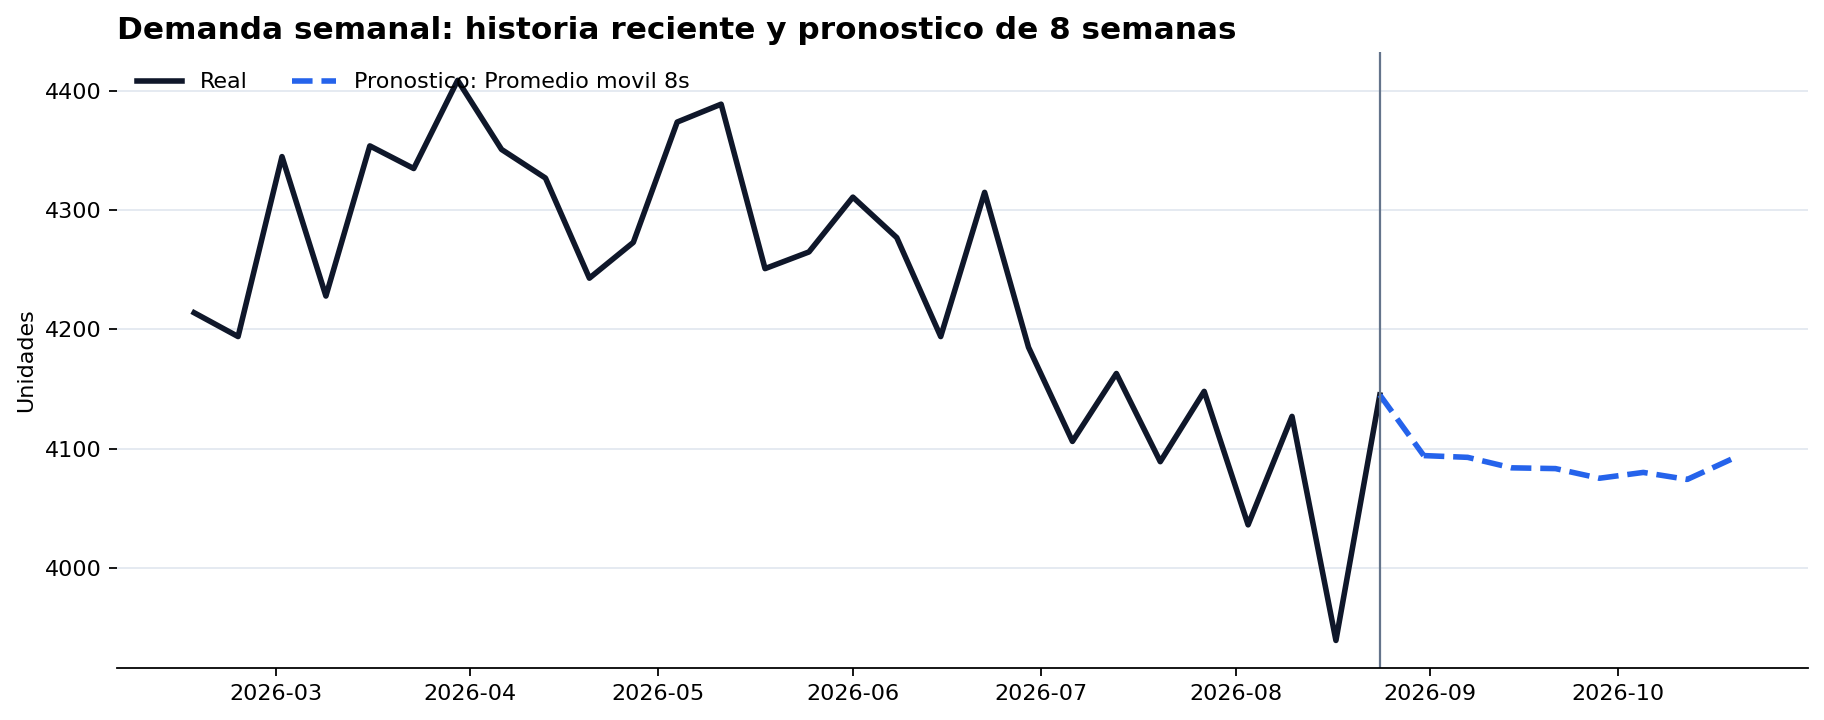

In [4]:
from IPython.display import Image, display
display(Image(filename=ROOT / 'images' / 'forecast_history.png'))


**Decision:** se utiliza el metodo con menor WAPE agregado y se conserva el bias como control para evitar sobrepronosticar inventario.


## 2. Elasticidad precio

Para cada SKU se estima un modelo log-log con controles por distribucion, mes, canal, zona y punto de venta. El coeficiente de `log_price` se interpreta como elasticidad propia.

$$\ln(Q_{it}+0.5)=\alpha+\beta\ln(P_{it})+\gamma D_{it}+FE_{mes}+FE_{canal}+FE_{zona}+FE_{PDV}+\varepsilon_{it}$$


In [5]:
enriched = (fact.merge(customers[['pdv_id','channel','zone']], on='pdv_id')
            .merge(calendar[['week_id','month_num']], on='week_id'))

def estimate_elasticity(frame):
    frame = frame.copy()
    frame['log_units'] = np.log(frame['units_sold'].clip(lower=0)+0.5)
    frame['log_price'] = np.log(frame['net_price'].clip(lower=.01))
    dummies = pd.get_dummies(
        frame[['month_num','channel','zone','pdv_id']].astype(str),
        drop_first=True, dtype=float)
    x_frame = pd.concat([
        frame[['log_price','numeric_distribution']].reset_index(drop=True),
        dummies.reset_index(drop=True)], axis=1)
    X = np.column_stack([np.ones(len(x_frame)), x_frame.to_numpy(dtype=float)])
    y = frame['log_units'].to_numpy(dtype=float)
    coef, _, rank, _ = np.linalg.lstsq(X, y, rcond=None)
    residual = y-X@coef
    sigma2 = (residual@residual)/max(len(y)-rank, 1)
    covariance = sigma2*np.linalg.pinv(X.T@X)
    r2 = 1-(residual@residual)/np.sum((y-y.mean())**2)
    return coef[1], np.sqrt(covariance[1,1]), r2

elasticity_rows = []
for sku, group in enriched.groupby('sku'):
    estimate, standard_error, r2 = estimate_elasticity(group)
    elasticity_rows.append([sku, estimate, standard_error, r2])
elasticity = pd.DataFrame(elasticity_rows,
    columns=['sku','estimated_own_elasticity','standard_error','r_squared'])
elasticity = elasticity.merge(products[['sku','product']], on='sku')
elasticity[['sku','product','estimated_own_elasticity','standard_error','r_squared']]


     sku       product  estimated_own_elasticity  standard_error  r_squared
CFCL-355  Cafe Clasico                    -1.097           0.090      0.644
CFVN-355 Cafe Vainilla                    -1.135           0.103      0.586
CFMO-355     Cafe Moka                    -1.741           0.117      0.542
TELM-500      Te Limon                    -0.738           0.095      0.629
FRTR-500 Bebida Frutal                    -0.937           0.100      0.607
ENRG-473    Energetica                    -0.703           0.121      0.504

## 3. Limitaciones y uso responsable

- Los datos son sinteticos; las elasticidades ilustran el proceso, no una recomendacion real de precios.
- Las elasticidades cruzadas del simulador son supuestos controlados y deben recalibrarse con experimentos o variacion historica suficiente.
- El modelo lineal de escenarios se restringe a descuentos de 0% a 20%.
- Antes de implementar una promocion se requiere validar capacidad, inventario, ejecucion y restricciones comerciales.
